In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score 

In [52]:
df = pd.read_csv('Bank Customer Churn Prediction-1.csv')

df = df.drop(columns=[col for col in df.columns if col.lower() in ['rownumber','customerid','surname']], errors='ignore')

df = pd.get_dummies(df, drop_first=True)

y = df['churn']
X = df.drop(columns=['churn'])

X = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
model = sm.Logit(y_train, X_train).fit()
print(model.summary())
print("Pseudo R-squared:", model.prsquared)

Optimization terminated successfully.
         Current function value: 0.438437
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                 8000
Model:                          Logit   Df Residuals:                     7990
Method:                           MLE   Df Model:                            9
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.1368
Time:                        18:04:19   Log-Likelihood:                -3507.5
converged:                       True   LL-Null:                       -4063.5
Covariance Type:            nonrobust   LLR p-value:                1.227e-233
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -3.3848      0.270    -12.559      0.000      -3.913      -2.857
credit_scor

In [54]:
print("Credit Score Coefficient:", model.params.get('credit_score', 'Not found'))
print("Active Member Coefficient:", model.params.get('active_member', 'Not found'))

Credit Score Coefficient: -0.0006893659788894294
Active Member Coefficient: -1.0710789868768826


Train AUC: 0.7529844207209235
Test AUC: 0.7652889473692543


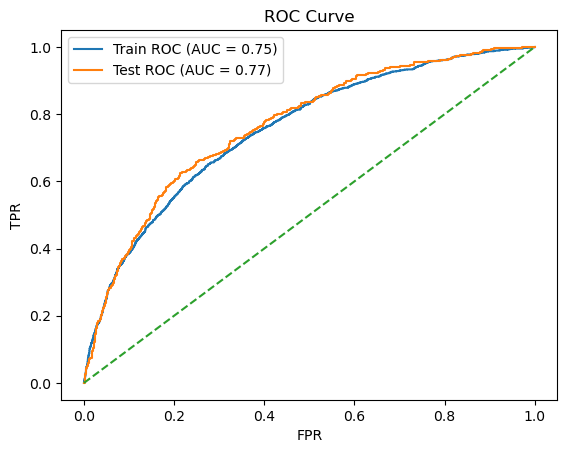

In [55]:
train_pred_prob = model.predict(X_train)
test_pred_prob = model.predict(X_test)

fpr_train, tpr_train, _ = roc_curve(y_train, train_pred_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, test_pred_prob)

auc_train = metrics.auc(fpr_train, tpr_train)
auc_test = metrics.auc(fpr_test, tpr_test)

print("Train AUC:", auc_train)
print("Test AUC:", auc_test)

plt.figure()
plt.plot(fpr_train, tpr_train, label='Train ROC (AUC = %0.2f)' % auc_train)
plt.plot(fpr_test, tpr_test, label='Test ROC (AUC = %0.2f)' % auc_test)
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.title('ROC Curve')
plt.show()

In [56]:
test_pred_class = (test_pred_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, test_pred_class)
print("Confusion Matrix:\n", cm)

TN, FP, FN, TP = cm.ravel()

MR = (FP + FN) / (TP + TN + FP + FN)
TPR = TP / (TP + FN)
FNR = FN / (FN + TP)

print("Misclassification Rate (MR):", MR)
print("True Positive Rate (TPR):", TPR)
print("False Negative Rate (FNR):", FNR)

Confusion Matrix:
 [[1562   45]
 [ 326   67]]
Misclassification Rate (MR): 0.1855
True Positive Rate (TPR): 0.17048346055979643
False Negative Rate (FNR): 0.8295165394402035
